## Data Acquisition, Cleaning, and Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("dirty_cafe_sales.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 8


In [6]:


print(df.columns.tolist())

['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']


In [7]:
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [9]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [10]:


missing_values = df.isnull().sum()

print(missing_values)


Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


In [11]:

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

In [12]:


missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
Transaction ID,0,0.00
Item,333,3.33
Quantity,138,1.38
Price Per Unit,179,1.79
Total Spent,173,1.73
Payment Method,2579,25.79
Location,3265,32.65
Transaction Date,159,1.59


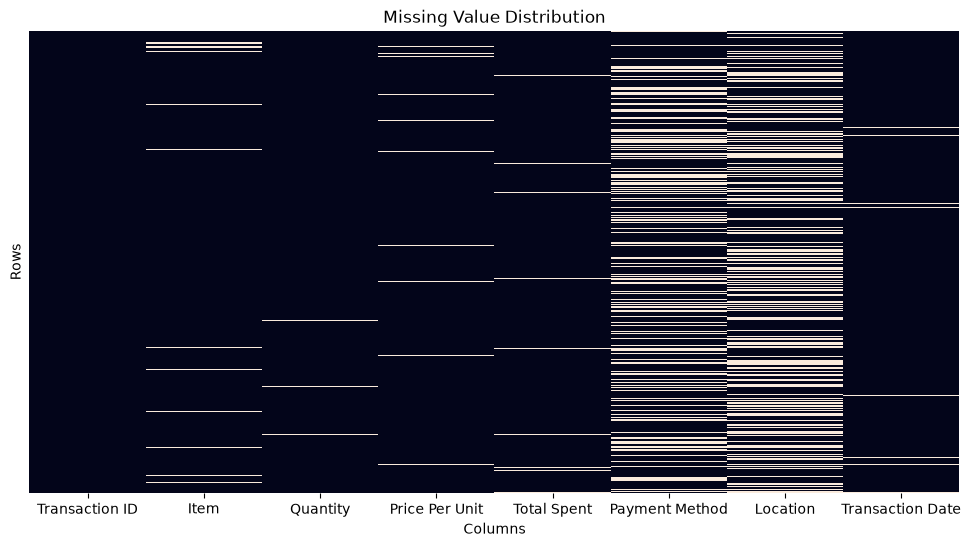

In [13]:


plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Distribution")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [14]:
# Find the most frequent Item

item_mode = df["Item"].mode()[0]

print("Most frequent item:", item_mode)

Most frequent item: Juice


In [15]:
# Fill missing Item values with the most frequent item

df["Item"] = df["Item"].fillna(item_mode)

In [16]:
# Check remaining missing Item values

print("Missing Item values:", df["Item"].isnull().sum())

Missing Item values: 0


In [17]:
# Check unique values in Quantity

df["Quantity"].unique()

<StringArray>
['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan]
Length: 8, dtype: str

In [18]:

# Convert Quantity from string to numeric

df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)


In [19]:
# Check unique values in Price Per Unit

df["Price Per Unit"].unique()

<StringArray>
['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN']
Length: 9, dtype: str

In [20]:
df["Price Per Unit"] = pd.to_numeric(
    df["Price Per Unit"],
    errors="coerce"
)

In [21]:
# Check unique values in Total Spent

df["Total Spent"].unique()

<StringArray>
[    '4.0',    '12.0',   'ERROR',    '10.0',    '20.0',     '9.0',    '16.0',
    '15.0',    '25.0',     '8.0',     '5.0',     '3.0',     '6.0',       nan,
 'UNKNOWN',     '2.0',     '1.0',     '7.5',     '4.5',     '1.5']
Length: 20, dtype: str

In [22]:
# Convert Total Spent to numeric

df["Total Spent"] = pd.to_numeric(
    df["Total Spent"],
    errors="coerce"
)

In [23]:
df["Transaction Date"].unique()

<StringArray>
['2023-09-08', '2023-05-16', '2023-07-19', '2023-04-27', '2023-06-11',
 '2023-03-31', '2023-10-06', '2023-10-28', '2023-07-28', '2023-12-31',
 ...
 '2023-08-01', '2023-01-20', '2023-11-11', '2023-02-13', '2023-07-30',
 '2023-02-17', '2023-05-20', '2023-11-05', '2023-03-27', '2023-07-03']
Length: 368, dtype: str

In [24]:
# Convert Transaction Date to datetime

df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

In [25]:
df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [26]:
# Fill missing Quantity values with the median

df["Quantity"] = df["Quantity"].fillna(
    df["Quantity"].median()
)

In [27]:
# Fill missing Price Per Unit values with the median

df["Price Per Unit"] = df["Price Per Unit"].fillna(
    df["Price Per Unit"].median()
)

In [28]:
# Calculate Total Spent using Quantity and Price Per Unit

calculated_total = (
    df["Quantity"] * df["Price Per Unit"]
)

df["Total Spent"] = df["Total Spent"].fillna(
    calculated_total
)

In [29]:
# Replace missing Payment Method values with Unknown

df["Payment Method"] = df["Payment Method"].fillna("Unknown")

In [30]:
# Replace missing Location values with Unknown

df["Location"] = df["Location"].fillna("Unknown")


In [31]:
# Compare missing values before and after treatment

comparison = pd.DataFrame({
    "Before Treatment": missing_values,
    "After Treatment": df.isnull().sum()
})

comparison

,Before Treatment,After Treatment
Transaction ID,0,0
Item,333,0
Quantity,138,0
Price Per Unit,179,0
Total Spent,173,0
Payment Method,2579,0
Location,3265,0
Transaction Date,159,460


In [32]:
# Display rows where Transaction Date is missing or invalid

df[df["Transaction Date"].isna()].head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
11,TXN_3051279,Sandwich,2.0,4.0,8.0,Credit Card,Takeaway,NaT
29,TXN_7640952,Cake,4.0,3.0,12.0,Digital Wallet,Takeaway,NaT
33,TXN_7710508,UNKNOWN,5.0,1.0,5.0,Cash,Unknown,NaT
77,TXN_2091733,Salad,1.0,5.0,5.0,Unknown,In-store,NaT
103,TXN_7028009,Cake,4.0,3.0,12.0,Unknown,Takeaway,NaT
104,TXN_7447872,Juice,2.0,3.0,6.0,Unknown,Unknown,NaT
115,TXN_1001832,Salad,2.0,5.0,10.0,Cash,Takeaway,NaT
142,TXN_7943008,Coffee,1.0,2.0,2.0,Credit Card,Unknown,NaT
160,TXN_1093800,Sandwich,3.0,4.0,12.0,Cash,Takeaway,NaT
175,TXN_6463132,Cookie,5.0,1.0,5.0,Credit Card,Takeaway,NaT


## Treatment of Missing Transaction Dates

The Transaction Date column contained missing and invalid date entries. During conversion to datetime format, invalid date values were converted to NaT using errors="coerce".

After conversion, 460 records had missing or invalid transaction dates.

The missing dates were not replaced with an arbitrary date because the actual transaction dates could not be reliably determined from the available information. The NaT values were therefore retained to avoid introducing fabricated information into the dataset.

This approach preserves the integrity of the available data, although records with missing dates cannot be used for time-based analysis unless their dates are later recovered from the original source.

In [33]:
# Count the missing/invalid transaction dates

print("Missing or invalid Transaction Dates:",
      df["Transaction Date"].isna().sum())

Missing or invalid Transaction Dates: 460


In [34]:
df.duplicated
print("the number of duplucated values:",df.duplicated().sum())

the number of duplucated values: 0


### Finding

The dataset contains no duplicate rows. Therefore, no duplicate records were removed.

In [35]:
# Check unique Item values

print(df["Item"].value_counts(dropna=False),"\n\n")
# Check unique Payment Method values

print(df["Payment Method"].value_counts(dropna=False),"\n\n")
# Check unique Location values

print(df["Location"].value_counts(dropna=False))


Item
Juice       1504
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64 


Payment Method
Unknown           2579
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64 


Location
Unknown     3265
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64


In [36]:
# Standardize different forms of unknown values

for column in ["Item", "Payment Method", "Location"]:
    df[column] = df[column].replace(
        ["UNKNOWN", "unknown", "Unknown"],
        "Unknown"
    )

In [37]:
# Check whether different forms of Unknown still exist

for column in ["Item", "Payment Method", "Location"]:
    print("\n", column)
    print(df[column].value_counts(dropna=False))


 Item
Item
Juice       1504
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Unknown      344
ERROR        292
Name: count, dtype: int64

 Payment Method
Payment Method
Unknown           2872
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
Name: count, dtype: int64

 Location
Location
Unknown     3603
Takeaway    3022
In-store    3017
ERROR        358
Name: count, dtype: int64


In [38]:
# Check minimum and maximum values of numerical columns

print("Quantity:")
print("Minimum:", df["Quantity"].min())
print("Maximum:", df["Quantity"].max())

print("\nPrice Per Unit:")
print("Minimum:", df["Price Per Unit"].min())
print("Maximum:", df["Price Per Unit"].max())

print("\nTotal Spent:")
print("Minimum:", df["Total Spent"].min())
print("Maximum:", df["Total Spent"].max())

Quantity:
Minimum: 1.0
Maximum: 5.0

Price Per Unit:
Minimum: 1.0
Maximum: 5.0

Total Spent:
Minimum: 1.0
Maximum: 25.0


In [39]:
# Count negative values in numerical columns

print("Negative Quantity:",
      (df["Quantity"] < 0).sum())

print("Negative Price Per Unit:",
      (df["Price Per Unit"] < 0).sum())

print("Negative Total Spent:",
      (df["Total Spent"] < 0).sum())

Negative Quantity: 0
Negative Price Per Unit: 0
Negative Total Spent: 0


In [40]:
# Calculate expected Total Spent

expected_total = (
    df["Quantity"] * df["Price Per Unit"]
)

In [41]:
# Calculate the difference between recorded and expected Total Spent

difference = (
    df["Total Spent"] - expected_total
)

print(difference.describe())

count    10000.000000
mean        -0.017400
std          1.403903
min        -10.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         16.000000
dtype: float64


In [42]:
# Identify records where Total Spent does not match Quantity × Price Per Unit

inconsistent_total = df[
    ~np.isclose(
        df["Total Spent"],
        expected_total,
        equal_nan=True
    )
]

print("Number of inconsistent Total Spent records:",
      len(inconsistent_total))

Number of inconsistent Total Spent records: 733


In [43]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Unknown,Unknown,2023-08-30
9996,TXN_9659401,Juice,3.0,3.0,3.0,Digital Wallet,Unknown,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Unknown,2023-03-02
9998,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,Unknown,2023-12-02
9999,TXN_6170729,Sandwich,3.0,4.0,12.0,Cash,In-store,2023-11-07


In [44]:
# Display inconsistent Total Spent records

inconsistent_total[
    [
        "Item",
        "Quantity",
        "Price Per Unit",
        "Total Spent",
        "Payment Method",
        "Location"
    ]
].head(20)

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
20,Smoothie,3.0,4.0,20.0,Cash,In-store
55,Cookie,3.0,1.0,2.0,Credit Card,Takeaway
57,Cake,3.0,3.0,3.0,Digital Wallet,In-store
66,Juice,3.0,3.0,6.0,Cash,Unknown
68,Salad,2.0,3.0,10.0,Unknown,In-store
85,Tea,3.0,3.0,4.5,Cash,Unknown
147,Salad,4.0,3.0,20.0,Cash,In-store
151,Juice,4.0,3.0,16.0,Credit Card,Takeaway
153,Unknown,3.0,3.0,12.0,Cash,In-store
162,Cookie,1.0,3.0,1.0,ERROR,Takeaway


In [46]:
# Create a column showing the expected Total Spent

inconsistent_total = inconsistent_total.copy()

inconsistent_total["Expected Total"] = (
    inconsistent_total["Quantity"] *
    inconsistent_total["Price Per Unit"]
)

inconsistent_total[
    [
        "Item",
        "Quantity",
        "Price Per Unit",
        "Total Spent",
        "Expected Total"
    ]
].head(20)

,Item,Quantity,Price Per Unit,Total Spent,Expected Total
20,Smoothie,3.0,4.0,20.0,12.0
55,Cookie,3.0,1.0,2.0,3.0
57,Cake,3.0,3.0,3.0,9.0
66,Juice,3.0,3.0,6.0,9.0
68,Salad,2.0,3.0,10.0,6.0
85,Tea,3.0,3.0,4.5,9.0
147,Salad,4.0,3.0,20.0,12.0
151,Juice,4.0,3.0,16.0,12.0
153,Unknown,3.0,3.0,12.0,9.0
162,Cookie,1.0,3.0,1.0,3.0


In [48]:
# Calculate the difference between recorded and expected Total Spent

inconsistent_total["Difference"] = (
    inconsistent_total["Total Spent"] -
    inconsistent_total["Expected Total"]
)

inconsistent_total[
    [
        "Quantity",
        "Price Per Unit",
        "Total Spent",
        "Expected Total",
        "Difference"
    ]
].head(20)

,Quantity,Price Per Unit,Total Spent,Expected Total,Difference
20,3.0,4.0,20.0,12.0,8.0
55,3.0,1.0,2.0,3.0,-1.0
57,3.0,3.0,3.0,9.0,-6.0
66,3.0,3.0,6.0,9.0,-3.0
68,2.0,3.0,10.0,6.0,4.0
85,3.0,3.0,4.5,9.0,-4.5
147,4.0,3.0,20.0,12.0,8.0
151,4.0,3.0,16.0,12.0,4.0
153,3.0,3.0,12.0,9.0,3.0
162,1.0,3.0,1.0,3.0,-2.0


In [49]:
# Check whether Total Spent and Expected Total are actually different

inconsistent_total["Difference"].value_counts().head(20)

Difference
 4.0     70
-3.0     68
 2.0     62
-4.0     62
-2.0     50
-6.0     46
 3.0     46
 5.0     43
-8.0     39
 6.0     33
 8.0     32
 10.0    27
-10.0    25
 1.0     24
-5.0     23
-1.0     20
-1.5     20
-7.5     17
-4.5     11
 1.5     10
Name: count, dtype: int64

In [50]:
# Show the range of differences

print(inconsistent_total["Difference"].describe())

count    733.000000
mean      -0.237381
std        5.183675
min      -10.000000
25%       -4.000000
50%       -1.000000
75%        4.000000
max       16.000000
Name: Difference, dtype: float64


In [51]:
# Check the unique values in the inconsistent records

print("Total inconsistent records:", len(inconsistent_total))

print("\nItems:")
print(inconsistent_total["Item"].value_counts())

print("\nPayment Methods:")
print(inconsistent_total["Payment Method"].value_counts())

print("\nLocations:")
print(inconsistent_total["Location"].value_counts())

Total inconsistent records: 733

Items:
Item
Salad       104
Tea         104
Cookie      101
Coffee       99
Sandwich     89
Smoothie     88
Juice        66
Cake         34
Unknown      30
ERROR        18
Name: count, dtype: int64

Payment Methods:
Payment Method
Unknown           221
Credit Card       165
Digital Wallet    162
Cash              161
ERROR              24
Name: count, dtype: int64

Locations:
Location
Unknown     280
Takeaway    219
In-store    212
ERROR        22
Name: count, dtype: int64


In [52]:
# Compare recorded and expected Total Spent

inconsistent_total[
    [
        "Item",
        "Quantity",
        "Price Per Unit",
        "Total Spent",
        "Expected Total"
    ]
].head(20)

,Item,Quantity,Price Per Unit,Total Spent,Expected Total
20,Smoothie,3.0,4.0,20.0,12.0
55,Cookie,3.0,1.0,2.0,3.0
57,Cake,3.0,3.0,3.0,9.0
66,Juice,3.0,3.0,6.0,9.0
68,Salad,2.0,3.0,10.0,6.0
85,Tea,3.0,3.0,4.5,9.0
147,Salad,4.0,3.0,20.0,12.0
151,Juice,4.0,3.0,16.0,12.0
153,Unknown,3.0,3.0,12.0,9.0
162,Cookie,1.0,3.0,1.0,3.0


In [54]:
# Preserve the original Total Spent values before correction

df["Original Total Spent"] = df["Total Spent"]
# Calculate the correct Total Spent

expected_total = (
    df["Quantity"] * df["Price Per Unit"]
)

# Replace incorrect Total Spent values with the calculated values

df["Total Spent"] = expected_total

In [55]:
# Check whether Total Spent is now consistent

expected_total = (
    df["Quantity"] * df["Price Per Unit"]
)

inconsistent_after = df[
    ~np.isclose(
        df["Total Spent"],
        expected_total,
        equal_nan=True
    )
]

print(
    "Inconsistent records after correction:",
    len(inconsistent_after)
)

Inconsistent records after correction: 0


In [57]:
# Display original and corrected Total Spent values

df[
    [
        "Quantity",
        "Price Per Unit",
        "Original Total Spent",
        "Total Spent"
    ]
].head(20)

,Quantity,Price Per Unit,Original Total Spent,Total Spent
0,2.0,2.0,4.0,4.0
1,4.0,3.0,12.0,12.0
2,4.0,1.0,4.0,4.0
3,2.0,5.0,10.0,10.0
4,2.0,2.0,4.0,4.0
5,5.0,4.0,20.0,20.0
6,3.0,3.0,9.0,9.0
7,4.0,4.0,16.0,16.0
8,5.0,3.0,15.0,15.0
9,5.0,4.0,20.0,20.0


In [58]:
# Select numerical columns for outlier analysis

numerical_columns = [
    "Quantity",
    "Price Per Unit",
    "Total Spent"
]

df[numerical_columns].describe()

,Quantity,Price Per Unit,Total Spent
count,10000.000000,10000.00000,10000.000000
mean,3.027100,2.95265,8.948150
std,1.384614,1.24396,5.831191
min,1.000000,1.00000,1.000000
25%,2.000000,2.00000,4.000000
50%,3.000000,3.00000,8.000000
75%,4.000000,4.00000,12.000000
max,5.000000,5.00000,25.000000


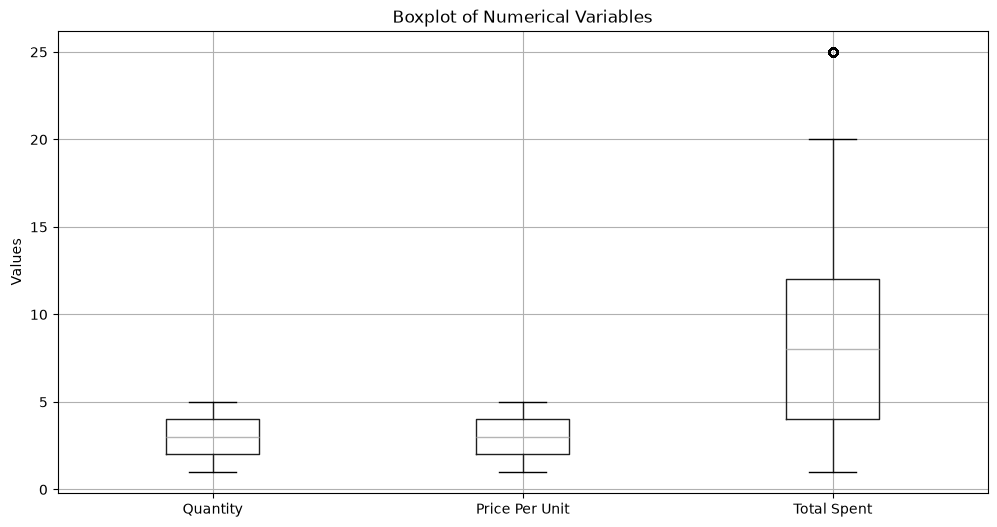

In [59]:
# Create boxplots to visually identify potential outliers

plt.figure(figsize=(12, 6))

df[numerical_columns].boxplot()

plt.title("Boxplot of Numerical Variables")
plt.ylabel("Values")

plt.show()

In [60]:
# Calculate Q1, Q3 and IQR for each numerical column

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    # Calculate outlier boundaries

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("\nColumn:", column)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)


Column: Quantity
Q1: 2.0
Q3: 4.0
IQR: 2.0

Column: Price Per Unit
Q1: 2.0
Q3: 4.0
IQR: 2.0

Column: Total Spent
Q1: 4.0
Q3: 12.0
IQR: 8.0

Column: Quantity
Lower Bound: -1.0
Upper Bound: 7.0

Column: Price Per Unit
Lower Bound: -1.0
Upper Bound: 7.0

Column: Total Spent
Lower Bound: -8.0
Upper Bound: 24.0


In [62]:
# Count potential outliers

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(
        column,
        ":",
        len(outliers),
        "potential outliers"
    )

Quantity : 0 potential outliers
Price Per Unit : 0 potential outliers
Total Spent : 240 potential outliers


In [63]:
# Display potential Total Spent outliers

Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

total_spent_outliers = df[
    (df["Total Spent"] < lower_bound) |
    (df["Total Spent"] > upper_bound)
]

total_spent_outliers[
    [
        "Transaction ID",
        "Item",
        "Quantity",
        "Price Per Unit",
        "Original Total Spent",
        "Total Spent"
    ]
]

,Transaction ID,Item,Quantity,Price Per Unit,Original Total Spent,Total Spent
10,TXN_2548360,Salad,5.0,5.0,25.0,25.0
51,TXN_6342161,Salad,5.0,5.0,25.0,25.0
52,TXN_8914892,Unknown,5.0,5.0,25.0,25.0
96,TXN_5220895,Salad,5.0,5.0,25.0,25.0
100,TXN_9517146,Juice,5.0,5.0,25.0,25.0
...,...,...,...,...,...,...
9791,TXN_1232346,Salad,5.0,5.0,25.0,25.0
9805,TXN_9506076,Salad,5.0,5.0,25.0,25.0
9879,TXN_6393305,Salad,5.0,5.0,25.0,25.0
9908,TXN_8922585,Salad,5.0,5.0,25.0,25.0


In [64]:
# Display Total Spent outliers for inspection

total_spent_outliers[
    [
        "Transaction ID",
        "Item",
        "Quantity",
        "Price Per Unit",
        "Original Total Spent",
        "Total Spent"
    ]
].head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Original Total Spent,Total Spent
10,TXN_2548360,Salad,5.0,5.0,25.0,25.0
51,TXN_6342161,Salad,5.0,5.0,25.0,25.0
52,TXN_8914892,Unknown,5.0,5.0,25.0,25.0
96,TXN_5220895,Salad,5.0,5.0,25.0,25.0
100,TXN_9517146,Juice,5.0,5.0,25.0,25.0
150,TXN_8687151,Salad,5.0,5.0,25.0,25.0
157,TXN_4283157,Salad,5.0,5.0,25.0,25.0
330,TXN_5523450,Salad,5.0,5.0,25.0,25.0
536,TXN_2968827,Salad,5.0,5.0,25.0,25.0
546,TXN_6669417,Salad,5.0,5.0,25.0,25.0


In [65]:
# Check the minimum and maximum Total Spent among the outliers

print("Minimum outlier Total Spent:",
      total_spent_outliers["Total Spent"].min())

print("Maximum outlier Total Spent:",
      total_spent_outliers["Total Spent"].max())

Minimum outlier Total Spent: 25.0
Maximum outlier Total Spent: 25.0


In [66]:
# Verify whether the outlier Total Spent values are mathematically correct

total_spent_outliers["Expected Total"] = (
    total_spent_outliers["Quantity"] *
    total_spent_outliers["Price Per Unit"]
)

total_spent_outliers[
    [
        "Quantity",
        "Price Per Unit",
        "Total Spent",
        "Expected Total"
    ]
].head(20)

,Quantity,Price Per Unit,Total Spent,Expected Total
10,5.0,5.0,25.0,25.0
51,5.0,5.0,25.0,25.0
52,5.0,5.0,25.0,25.0
96,5.0,5.0,25.0,25.0
100,5.0,5.0,25.0,25.0
150,5.0,5.0,25.0,25.0
157,5.0,5.0,25.0,25.0
330,5.0,5.0,25.0,25.0
536,5.0,5.0,25.0,25.0
546,5.0,5.0,25.0,25.0


In [67]:
# Check final data types

df.dtypes

Transaction ID                     str
Item                               str
Quantity                       float64
Price Per Unit                 float64
Total Spent                    float64
Payment Method                     str
Location                           str
Transaction Date        datetime64[us]
Original Total Spent           float64
dtype: object

In [68]:
# Check final dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 9


In [69]:
# Save the final cleaned dataset

df.to_csv("cleaned_customer_transactions.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
# Read the saved file and verify its size

cleaned_df = pd.read_csv("cleaned_customer_transactions.csv")
print("Saved dataset shape:", cleaned_df.shape)

Saved dataset shape: (10000, 9)
